In [13]:
import tensorflow as tf
import pandas as pd
import numpy as np
print("TensorFlow version:", tf.__version__)
print("All imports successful!")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt


TensorFlow version: 2.21.0
All imports successful!


In [2]:
df = pd.read_csv('BostonHousing.csv')

In [3]:
print(df.head(10))

       crim     zn  indus  chas    nox     rm   age     dis  rad  tax  \
0   9.36350  95.07  22.09     0  0.658  5.952  10.9   6.052   21  249   
1  23.46382   0.08  29.77     0  0.483  6.386  43.8   4.204   10  625   
2   9.56155  98.32  14.27     0  0.665  4.438   7.4  11.438   14  391   
3  17.08159  61.00  25.08     0  0.846  4.923  66.6   4.429    6  715   
4  23.48747  89.48  18.14     1  0.496  6.637  52.6  11.573   21  487   
5   6.89998  29.63   5.38     0  0.892  7.747  20.7   1.061   11  648   
6   8.96164  11.59  25.96     1  0.570  4.025  37.7   8.357    5  248   
7  24.29280  84.89  21.79     0  0.763  6.216  52.8   5.703   10  610   
8  17.38790  13.93  18.33     0  0.753  4.758   8.6   4.187   22  727   
9   5.46101  41.65  26.56     1  0.784  8.429  32.5   2.211   20  408   

   ptratio        b   lstat   medv  
0    12.14  260.355   3.200  37.49  
1    24.61   93.109   4.534  32.83  
2    15.78    6.387  10.005  15.85  
3    18.20   73.942  38.814  39.88  
4    18.10 

In [4]:
print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [5]:
print(df.info)

<bound method DataFrame.info of         crim     zn  indus  chas    nox     rm   age     dis  rad  tax  \
0    9.36350  95.07  22.09     0  0.658  5.952  10.9   6.052   21  249   
1   23.46382   0.08  29.77     0  0.483  6.386  43.8   4.204   10  625   
2    9.56155  98.32  14.27     0  0.665  4.438   7.4  11.438   14  391   
3   17.08159  61.00  25.08     0  0.846  4.923  66.6   4.429    6  715   
4   23.48747  89.48  18.14     1  0.496  6.637  52.6  11.573   21  487   
5    6.89998  29.63   5.38     0  0.892  7.747  20.7   1.061   11  648   
6    8.96164  11.59  25.96     1  0.570  4.025  37.7   8.357    5  248   
7   24.29280  84.89  21.79     0  0.763  6.216  52.8   5.703   10  610   
8   17.38790  13.93  18.33     0  0.753  4.758   8.6   4.187   22  727   
9    5.46101  41.65  26.56     1  0.784  8.429  32.5   2.211   20  408   
10   2.99663  33.76  28.32     1  0.431  6.570  41.0   1.714   20  417   
11   0.92217  60.96  15.33     1  0.320  5.398  63.8   8.488   21  565   
12  20

In [6]:
print(df.describe)

<bound method NDFrame.describe of         crim     zn  indus  chas    nox     rm   age     dis  rad  tax  \
0    9.36350  95.07  22.09     0  0.658  5.952  10.9   6.052   21  249   
1   23.46382   0.08  29.77     0  0.483  6.386  43.8   4.204   10  625   
2    9.56155  98.32  14.27     0  0.665  4.438   7.4  11.438   14  391   
3   17.08159  61.00  25.08     0  0.846  4.923  66.6   4.429    6  715   
4   23.48747  89.48  18.14     1  0.496  6.637  52.6  11.573   21  487   
5    6.89998  29.63   5.38     0  0.892  7.747  20.7   1.061   11  648   
6    8.96164  11.59  25.96     1  0.570  4.025  37.7   8.357    5  248   
7   24.29280  84.89  21.79     0  0.763  6.216  52.8   5.703   10  610   
8   17.38790  13.93  18.33     0  0.753  4.758   8.6   4.187   22  727   
9    5.46101  41.65  26.56     1  0.784  8.429  32.5   2.211   20  408   
10   2.99663  33.76  28.32     1  0.431  6.570  41.0   1.714   20  417   
11   0.92217  60.96  15.33     1  0.320  5.398  63.8   8.488   21  565   
12  

In [7]:
print(df.corr()['medv'].sort_values())

rm        -0.219467
chas      -0.114546
age       -0.070551
rad       -0.053644
tax        0.012157
indus      0.058789
zn         0.135230
ptratio    0.153714
lstat      0.153986
dis        0.176688
nox        0.179012
b          0.260099
crim       0.260212
medv       1.000000
Name: medv, dtype: float64


In [14]:
X = df.loc[:, df.columns != 'medv'].values
y = df.loc[:, df.columns == 'medv'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
model = Sequential(layers=[
    Dense(128, input_shape=(13,), activation='relu', name='dense_1'),
    Dense(64, activation='relu', name='dense_2'),
    Dense(1, activation='linear', name='dense_output')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()
model.fit(X_train, y_train, epochs=100, validation_split=0.05, verbose='auto')

/Users/manas/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 869.4362 - mae: 26.7540 - val_loss: 723.6370 - val_mae: 26.3213
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 856.2914 - mae: 26.5113 - val_loss: 712.0397 - val_mae: 26.1029
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 844.0889 - mae: 26.2882 - val_loss: 700.2778 - val_mae: 25.8800
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 832.1164 - mae: 26.0665 - val_loss: 688.0974 - val_mae: 25.6473
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 820.3025 - mae: 25.8442 - val_loss: 675.9064 - val_mae: 25.4126
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 808.3128 - mae: 25.6178 - val_loss: 663.2893 - val_mae: 25.1691
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 796.0967 - mae: 25.3854 - val_loss: 650.8329 - val_mae: 24.9249
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 783.6547 - mae: 25.1443 - val_loss: 638.2558 - val_mae: 24.6740
Epoch 9/100
2/2 ━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 262.5462 - mae: 13.9127
Mean squared error on test data:  262.54620361328125
Mean absolute error on test data:  13.912724494934082
Accuracy: -25.477254602110257


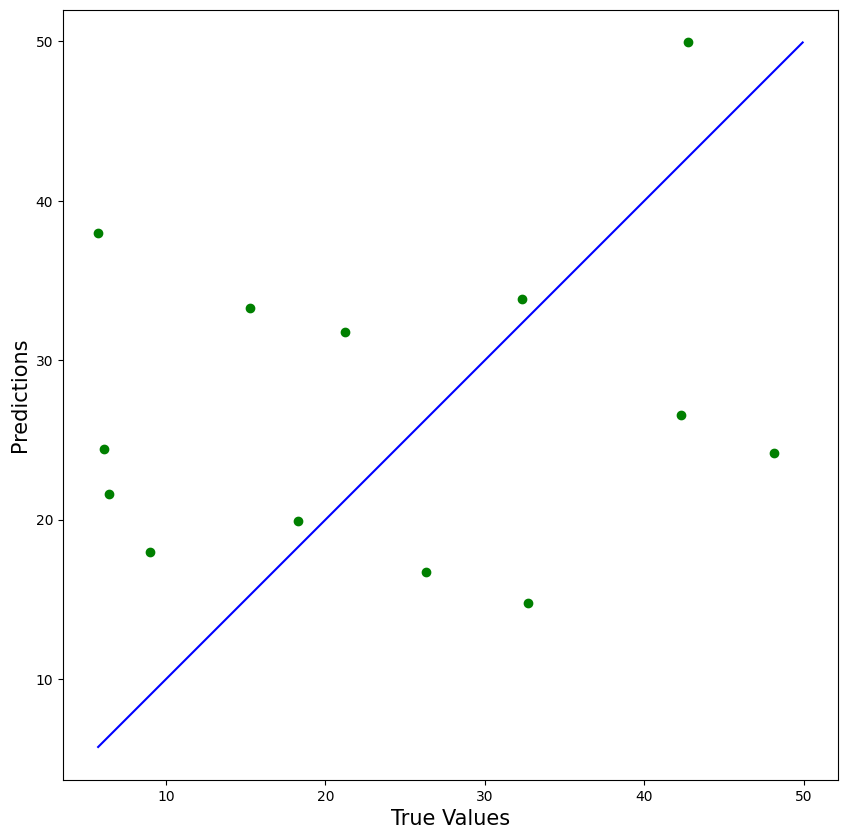

In [16]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
mse_nn, mae_nn = model.evaluate(X_test, y_test)
r2 = r2_score(y_test, y_pred)
print('Mean squared error on test data: ', mse_nn)
print('Mean absolute error on test data: ', mae_nn)
print('Accuracy:', r2 * 100)

plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred, c='green')
p1 = max(max(y_pred), max(y_test))
p2 = min(min(y_pred), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.show()